# Project 2: Netflix Data Analysis

In this project we will be working with a dataset of Netflix titles. We will be using its data to answer some questions about Netflix titles, directors, and countries using Pandas. We will also use Matplotlib to do a couple of interesting visualizations to get more interesting insights. The data is stored in a csv file named `netflix_titles.csv`.

Data extracted from: https://www.kaggle.com/datasets/shivamb/netflix-shows (with some cleaning and modifications).


### Project Tasks:

- `2.1.` Load the data using Pandas read_csv, use `show_id` as the index_col parameter.

- `2.2.` What is the min and max release years?  

- `2.3.` How many director names are missing values (NaN)?  

- `2.4.` How many different countries are there in the data?  

- `2.5.` How many characters long are on average the title names? (create a new column with the titles length if needed)  

- `2.6.` For a given year, make a pie chart of the number of movies and series combined made by every country, limit it to the top 10 countries.

- `2.7.` Make a line chart of the average duration of movies (not TV shows) in minutes for every year across all the years. (hint: you can create a new column with the integer value of the minutes and then use groupby year and then average on that minutes column)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Ex 2.1: Load the data using Pandas read_csv, use `show_id` as the index_col parameter. 

data_path = "../data/netflix_titles.csv"

movies_df = pd.read_csv(data_path, index_col="show_id")  # TODO

movies_df

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In [3]:
# Ex 2.2: What is the min and max release years?

min_year = movies_df["release_year"].min() # TODO
max_year = movies_df["release_year"].max() # TODO

print(f"Min year: {min_year}, Max year: {max_year}")

Min year: 1925, Max year: 2021


In [4]:
# Ex 2.3: How many director names are missing values (NaN)?

num_missing_directors = movies_df["director"].isna().sum()  # TODO

print(f"Number of missing directors: {num_missing_directors}")

Number of missing directors: 2634


In [5]:
# Ex 2.4: How many different countries are there in the data?

# Fill NaN values with "Unknown"
countries_filled = movies_df["country"].fillna("Unknown")

# Join all countries into a single string, then split by ", " to get individual countries
all_countries_str = ", ".join(countries_filled)
countries_list = all_countries_str.split(", ")

# Get unique countries using a set
unique_countries = set(countries_list)

# Get the count of unique countries
n_countries = len(unique_countries)

print(f"There are {n_countries} different countries in the data")

There are 128 different countries in the data


In [8]:
# Ex 2.5: How many characters long are on average the title names?

# Create a new column with the length of each title
movies_df["title_length"] = movies_df["title"].apply(lambda x: len(x))

# Calculate the average title length
avg_title_length = round(movies_df["title_length"].mean())

print(f"The average title length is {avg_title_length} characters")

The average title length is 18 characters


country
United States     43
India             20
United Kingdom    11
Germany            8
Japan              5
France             3
Australia          3
Turkey             3
Czech Republic     3
Canada             2
Name: count, dtype: int64


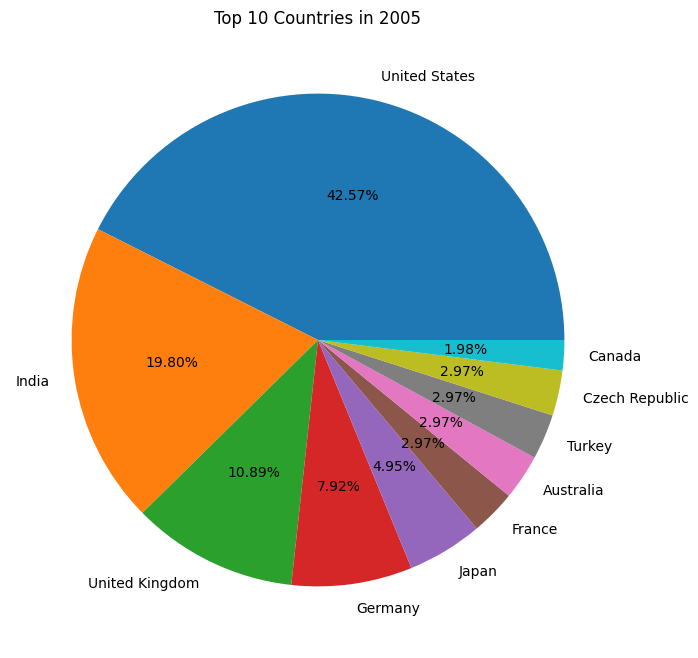

In [9]:
# Ex 2.6: For a given year, get the Pandas Series of how many movies and series combined were made by every country, limit it to the top 10 countries.

# It's optional to clean or modify the data of countries in this case, you can just use the data as it is.

# hint: (you can use the .loc method to filter the data by year, and then use the .value_counts() method to get the number of movies and series combined for each country, 
# finally use the head(10) method to get the top 10 countries)

year = 2005   # you can try to change the year to see the results for different years 

countries_series = movies_df.loc[movies_df["release_year"] == year, "country"].dropna().str.split(r',\s*').explode()

top_10_countries = top_10_countries = countries_series.value_counts().head(10)  # TODO: top_10_countries has to be a Pandas Series with the top 10 countries with the number of movies and series combined for that year

print(top_10_countries)

# Code to plot the pie chart from your data results
fig = plt.figure(figsize=(8, 8))
plt.pie(top_10_countries, labels=top_10_countries.index, autopct="%.2f%%")
plt.title(f"Top 10 Countries in {year}")

plt.show()


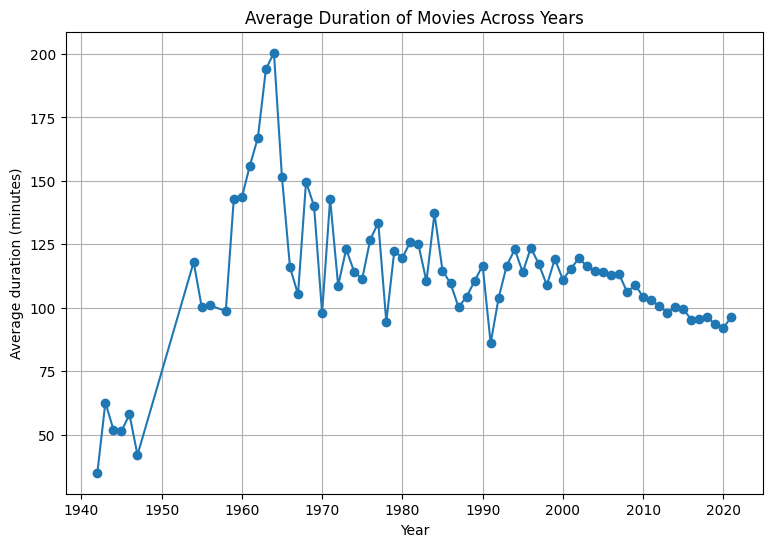

In [10]:
# Ex 2.7: Make a line chart of the average duration of movies (not TV shows) in minutes for every year across all the years. 

# (hint: you can create a new column with the integer value of the minutes of the movies, it's possible to do it with the .apply() 
# method and a lambda function, getting only stripping the minutes of it and converting the digit number to an integer
# or you can also do this process with a for loop over the dataframe rows like <for row_id, row in df.iterrows(): > creating every new value of that row for the new column

# Then use groupby year and in order to average on that movies minutes column)

# Keep only movies (handle possible NaN / case differences)
movies_only = movies_df[movies_df["type"].fillna("").str.lower() == "movie"].copy()

# Extract the integer minute value from the duration column (e.g. "90 min" -> 90)
movies_only["duration_min"] = pd.to_numeric(movies_only["duration"].str.extract(r"(\d+)")[0], errors="coerce")

# Group by release year and compute the mean duration (minutes)
movies_avg_duration_per_year = movies_only.groupby("release_year")["duration_min"].mean().dropna().sort_index()  # TODO: movies_avg_duration_per_year has to be a Pandas Series with the average duration of movies per year


fig = plt.figure(figsize=(9, 6))

# TODO: generate the line plot using plt.plot() and the information from movies_avg_duration_per_year (the vertical axis with the minutes value) and its index (the horizontal axis with the years)
plt.plot(movies_avg_duration_per_year.index, movies_avg_duration_per_year.values, marker="o", linestyle="-")
plt.xlabel("Year")
plt.ylabel("Average duration (minutes)")
plt.grid(True)
plt.title("Average Duration of Movies Across Years")

plt.show()